# Addis Ababa: HIPS/PTFE Operating Envelope

**Central question:** is Addis Ababa pushing SPARTAN HIPS/PTFE-filter absorption measurements outside the regime where the usual IMPROVE/SPARTAN assumptions behave well?

This notebook is a new research section for the Addis HIPS anomaly. It does not try to find one final correction. It organizes the next tests around an operating-envelope question:

1. Where do Addis filters sit in raw HIPS optical coordinates (`t`, `r`, `tau`)?
2. Does the HIPS-vs-FTIR residual track deposited mass per area rather than ambient concentration?
3. Does the anomaly look like slope/MAC mismatch, positive optical floor, nonlinear compression, or lot/calibration structure?
4. Which pieces are already handled in existing notebooks, and which still need new data such as AERONET SSA or SPARTAN support-screen geometry?


## Literature Mechanism Map

| Mechanism | Main literature hook | Analysis in this notebook |
|---|---|---|
| HIPS calibration / PTFE T-R interpretation | White et al. 2016, DOI `10.1080/02786826.2016.1211615` | raw HIPS optical regime and blank/lot handoff to `hips_offset_narrative.ipynb` |
| Patterned deposits / pixelation | White et al. 2025, DOI `10.1080/10962247.2024.2442634` | interpret Addis as a possible nonuniform-deposit boundary case; do not apply IMPROVE correction directly |
| PTFE optical-depth / SSA dependence | Pandey, Shetty & Chakrabarty 2019, DOI `10.5194/amt-12-1365-2019` | residual vs `OC`, `OC/EC`, `OM/EC`, `PM`, `HIPS_t`, `HIPS_r`, `HIPS_tau`; optional AERONET SSA hook |
| General filter photometer artifacts | Bond et al. 1999; Davies et al. 2019; Yus-Díez et al. 2025 | compare OLS, through-origin, and robust fits rather than relying on `r²` alone |
| Organic aerosol filter artifact | Lack et al. 2008; Cappa et al. 2008 | residual vs OC loading, OC/EC, OM/EC |
| MAC variation and terminology | Bond & Bergstrom 2006; Bond et al. 2013; Petzold et al. 2013; Ren et al. 2025 | separate through-origin effective MAC from intercept/floor; avoid treating optical eBC as identical to EC |
| Addis site/source context | Tefera et al. 2020/2021 and ETAD PMF data | season/source interpretation, but source splits are supporting rather than the main proof |
| Dust/iron absorption | Lafon et al. 2006; Fialho et al. 2005; Go et al. 2022 | keep Fe/dust as a checked mechanism, while existing AERONET coarse-AOD result argues against dust explaining the positive HIPS offset |


## What Has Already Been Done

| Proposed analysis | Existing coverage | Remaining gap here |
|---|---|---|
| Optical floor / Addis tau intercept | `research/ftir_hips_chem/hips_offset_narrative.ipynb` already shows Addis has a positive `HIPS_tau` floor and blanks are not large enough to explain it. | Replot all sites in raw optical coordinates and connect to mass/composition screens. |
| Blank / lot check | `hips_offset_narrative.ipynb` already does the strongest blank/lot audit. | Add quick lot/calibration grouping for residuals, not a full blank re-audit. |
| IMPROVE overlap | `research/ftir_hips_chem/improve_high_fabs_comparison.ipynb` and `research/improve_hips_offset/improve_addis_analog_audit.ipynb` already handle most IMPROVE high-fAbs/loading tests. | Do not duplicate; summarize SPARTAN envelope variables that should be matched against IMPROVE. |
| AERONET dust/coarse AOD | `cross_plots_and_distributions.ipynb`, `addis_04_aeronet*.ipynb`, and summaries already test AOD/coarse-mode filters. | Add an SSA-ready merge hook if inversion SSA files are available. |
| Residual vs composition/loading | Some source/iron/residual tests exist, but not as a compact operating-envelope screen across all proposed variables. | Primary new contribution of this notebook. |
| OLS / through-origin / robust fit separation | Existing IMPROVE notebooks do this for IMPROVE; SPARTAN notebooks do pieces of it. | Consolidate for SPARTAN HIPS vs FTIR EC by site and by Addis loading bins. |

## Standard Setup

Follows `/Users/ahmadjalil/github/aethmodular/AGENTS.md`: notebooks in this folder import from `./scripts`, use the centralized config/exclusion helpers, and avoid redefining plot styles after importing `plotting`.

In [1]:
import sys
sys.path.insert(0, './scripts')

from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Config + data
from config import SITES, PROCESSED_SITES_DIR, FILTER_DATA_PATH, MAC_VALUE

# Exclusions (use these — do not hand-filter)
from outliers import (
    EXCLUDED_SAMPLES, MANUAL_OUTLIERS,
    apply_exclusion_flags, apply_threshold_flags,
    get_clean_data, print_exclusion_summary,
)

# Data loading / matching
from data_matching import (
    load_aethalometer_data, load_filter_data,
    match_aeth_filter_data, match_all_parameters,
    load_etad_factor_contributions, match_etad_factors,
)

# Plotting — importing the package auto-applies the white-background default style.
from plotting import PlotConfig, crossplots, timeseries, distributions, comparisons
from plotting.utils import calculate_regression_stats

PlotConfig.set(sites='all', layout='individual', show_stats=True, show_1to1=True)

SITE_CODE_TO_NAME = {cfg['code']: site for site, cfg in SITES.items()}
SITE_ORDER = ['Beijing', 'Delhi', 'JPL', 'Addis_Ababa']
SITE_COLORS = {site: SITES[site]['color'] for site in SITE_ORDER}
OUT_DIR = Path('output/hips_ptfe_operating_envelope')
OUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 120)

## Build Filter-Level Operating-Envelope Table

The analysis is filter-level because HIPS sees the deposited material on the PTFE filter. Concentration is converted to surface loading as:

`loading_ug_cm2 = concentration_ug_m3 * Volume_m3 / DepositArea_cm2`

For `EC_ftir`, `OC_ftir`, and `OM`, the dataset already provides `MassLoading_ug`; this notebook uses that value when present and falls back to concentration × volume. `ChemSpec_Iron_PM2.5` is stored in `ng/m3`, so it is converted to `ug/m3` before calculating iron surface loading.

In [2]:
def first_nonmissing(series):
    s = series.dropna()
    return s.iloc[0] if len(s) else np.nan

PARAMS = [
    'HIPS_Fabs', 'HIPS_T1', 'HIPS_R1', 'HIPS_t', 'HIPS_r', 'HIPS_tau',
    'HIPS_Intercept', 'HIPS_Slope',
    'EC_ftir', 'OC_ftir', 'OM',
    'ChemSpec_Filter_PM2.5_mass', 'ChemSpec_Iron_PM2.5',
    'ChemSpec_OC_PM2.5', 'ChemSpec_EC_PM2.5',
]

filters = load_filter_data()
def base_filter_id(filter_id):
    text = str(filter_id)
    # HIPS/FTIR IDs often use SITE-0000-N; ChemSpec IDs such as SITE-0000 should stay intact.
    return pd.Series([text]).str.replace(r'^([A-Z]+-\d{4})-\d+$', r'\1', regex=True).iloc[0]

filters['base_filter_id'] = filters['FilterId'].map(base_filter_id)
filters['SiteName'] = filters['Site'].map(SITE_CODE_TO_NAME)
filters['SampleDate'] = pd.to_datetime(filters['SampleDate'])

sub = filters[filters['Parameter'].isin(PARAMS)].copy()

# Keep one metadata row per physical filter/date. Do not include fields such as
# AnalysisDate in the pivot index because HIPS, FTIR, and ChemSpec are analyzed
# at different times and would otherwise split into separate rows.
meta_cols = [
    'Site', 'SiteName', 'base_filter_id', 'SampleDate', 'FilterType', 'LotId',
    'DepositArea_cm2', 'Volume_m3'
]
meta = (
    sub.sort_values(['base_filter_id', 'SampleDate'])
    .groupby(['Site', 'SiteName', 'base_filter_id', 'SampleDate'], as_index=False)
    .agg({
        'FilterType': first_nonmissing,
        'LotId': first_nonmissing,
        'DepositArea_cm2': first_nonmissing,
        'Volume_m3': first_nonmissing,
    })
)

wide = (
    sub.pivot_table(
        index=['Site', 'SiteName', 'base_filter_id', 'SampleDate'],
        columns='Parameter',
        values='Concentration',
        aggfunc='first',
    )
    .reset_index()
)
wide.columns.name = None
wide = wide.merge(meta, on=['Site', 'SiteName', 'base_filter_id', 'SampleDate'], how='left')
wide = wide.rename(columns={'SampleDate': 'date'})
wide['date'] = pd.to_datetime(wide['date'])

# Attach representative HIPS analysis/calibration metadata from HIPS rows.
hips_meta = (
    filters[filters['Parameter'].astype(str).str.startswith('HIPS_')]
    .sort_values(['base_filter_id', 'AnalysisDate', 'AnalysisTime'])
    .groupby('base_filter_id', as_index=False)
    .agg({
        'AnalysisDate': first_nonmissing,
        'AnalysisTime': first_nonmissing,
        'CalibrationSetId': first_nonmissing,
    })
)
hips_meta['AnalysisDate'] = pd.to_datetime(hips_meta['AnalysisDate'], errors='coerce')
wide = wide.merge(hips_meta, on='base_filter_id', how='left')

# Ensure optional parameter columns exist even if a filtered subset is missing one.
for param in PARAMS:
    if param not in wide.columns:
        wide[param] = np.nan

# Attach direct FTIR mass loading where available.
for param, out_col in [('EC_ftir', 'ec_mass_ug'), ('OC_ftir', 'oc_mass_ug'), ('OM', 'om_mass_ug')]:
    mass = (
        sub[sub['Parameter'].eq(param)]
        .groupby('base_filter_id')['MassLoading_ug']
        .agg(first_nonmissing)
        .rename(out_col)
    )
    wide = wide.merge(mass, on='base_filter_id', how='left')

# Attach exclusion flags by site/date. This is non-destructive and preserves auditability.
flagged = []
for site, g in wide.groupby('SiteName', dropna=False):
    flagged.append(apply_exclusion_flags(g, site) if pd.notna(site) else g)
wide = pd.concat(flagged, ignore_index=True)
clean = get_clean_data(wide)

# Standard derived quantities.
clean['hips_bc'] = clean['HIPS_Fabs'] / MAC_VALUE
clean['hips_bc_loading_ug_cm2'] = clean['hips_bc'] * clean['Volume_m3'] / clean['DepositArea_cm2']
clean['ec_loading_ug_cm2'] = clean['ec_mass_ug'].fillna(clean['EC_ftir'] * clean['Volume_m3']) / clean['DepositArea_cm2']
clean['oc_loading_ug_cm2'] = clean['oc_mass_ug'].fillna(clean['OC_ftir'] * clean['Volume_m3']) / clean['DepositArea_cm2']
clean['om_loading_ug_cm2'] = clean['om_mass_ug'].fillna(clean['OM'] * clean['Volume_m3']) / clean['DepositArea_cm2']
clean['pm25_loading_ug_cm2'] = clean['ChemSpec_Filter_PM2.5_mass'] * clean['Volume_m3'] / clean['DepositArea_cm2']
clean['iron_ug_m3'] = clean['ChemSpec_Iron_PM2.5'] / 1000.0
clean['iron_loading_ug_cm2'] = clean['iron_ug_m3'] * clean['Volume_m3'] / clean['DepositArea_cm2']

clean['hips_minus_ec'] = clean['hips_bc'] - clean['EC_ftir']
clean['hips_minus_ec_rel'] = clean['hips_minus_ec'] / clean['EC_ftir']
clean['hips_to_ec'] = clean['hips_bc'] / clean['EC_ftir']
clean['oc_ec'] = clean['OC_ftir'] / clean['EC_ftir']
clean['om_ec'] = clean['OM'] / clean['EC_ftir']
clean['pm_ec'] = clean['ChemSpec_Filter_PM2.5_mass'] / clean['EC_ftir']
clean['iron_ec'] = clean['iron_ug_m3'] / clean['EC_ftir']
clean['month'] = clean['date'].dt.month
clean['year'] = clean['date'].dt.year

# Ethiopia seasons for Addis-specific residual plots.
def ethiopia_season(month):
    if month in [10, 11, 12, 1, 2]:
        return 'Dry Season'
    if month in [3, 4, 5]:
        return 'Belg Rainy Season'
    if month in [6, 7, 8, 9]:
        return 'Kiremt Rainy Season'
    return np.nan

clean['ethiopia_season'] = np.where(clean['SiteName'].eq('Addis_Ababa'), clean['month'].map(ethiopia_season), np.nan)

sample_clean = clean[clean['FilterType'].eq('PM2.5')].copy()
blank_clean = clean[clean['FilterType'].eq('FB')].copy()

availability = (
    clean.groupby('SiteName')[[
        'HIPS_Fabs', 'HIPS_t', 'HIPS_r', 'HIPS_tau', 'EC_ftir', 'OC_ftir', 'OM',
        'ChemSpec_Filter_PM2.5_mass', 'ChemSpec_Iron_PM2.5', 'Volume_m3', 'LotId'
    ]]
    .agg(lambda s: int(s.notna().sum()))
    .loc[SITE_ORDER]
)
print(f'Filter-level rows after registry exclusions: {len(clean):,}')
display(availability)

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


Filter-level rows after registry exclusions: 939


,HIPS_Fabs,HIPS_t,HIPS_r,HIPS_tau,EC_ftir,OC_ftir,OM,ChemSpec_Filter_PM2.5_mass,ChemSpec_Iron_PM2.5,Volume_m3,LotId
SiteName,,,,,,,,,,,
Beijing,163,163,163,163,186,186,186,360,341,186,192
Delhi,62,96,96,96,62,62,62,27,27,62,96
JPL,130,130,130,130,158,158,158,276,261,158,158
Addis_Ababa,190,190,190,190,190,190,190,188,188,190,190


## 1. Optical Regime Plot

This is the first operating-envelope figure: where do the SPARTAN samples sit in raw HIPS optical coordinates? If Addis is a boundary case, it should separate in `HIPS_t`, `HIPS_r`, and/or `HIPS_tau`, not just in converted `HIPS_Fabs / MAC`.

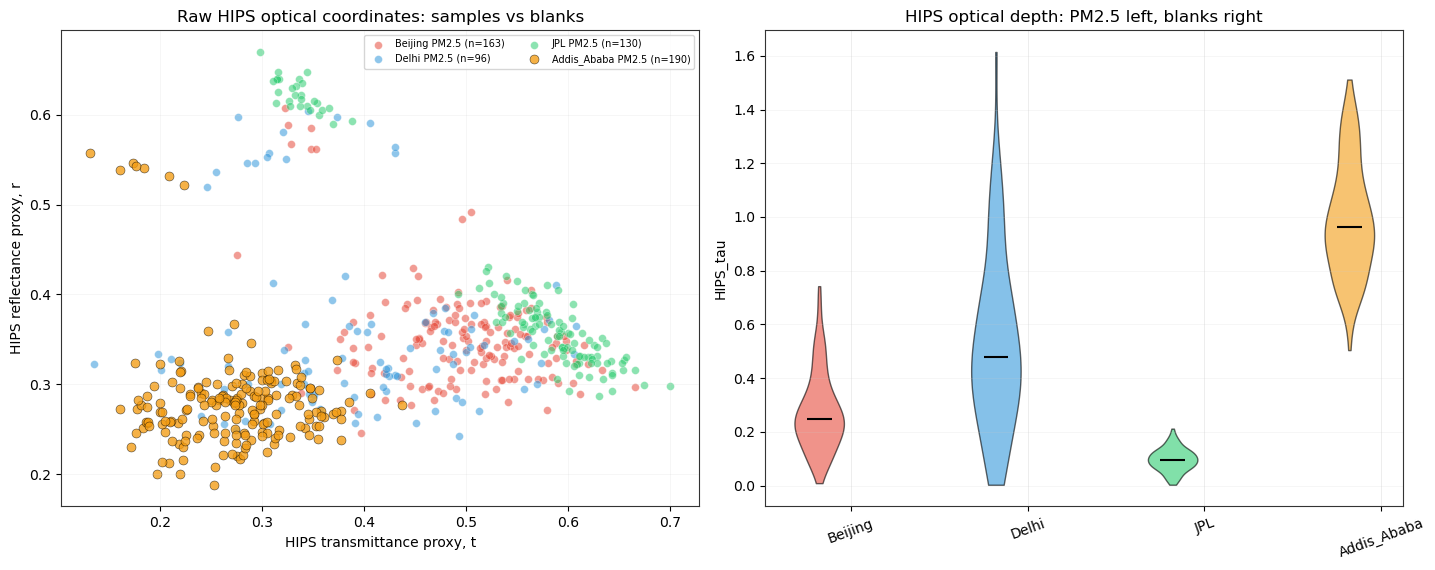

HIPS_t                                          \
                        count      mean       std       min        5%   
SiteName    FilterType                                                  
Beijing     PM2.5       163.0  0.494482  0.071674  0.275385  0.354392   
Delhi       PM2.5        96.0  0.392740  0.105447  0.134868  0.234430   
JPL         PM2.5       130.0  0.534641  0.110701  0.297491  0.315378   
Addis_Ababa PM2.5       190.0  0.271324  0.056752  0.131300  0.178982   

                                                                          \
                             25%       50%       75%       95%       max   
SiteName    FilterType                                                     
Beijing     PM2.5       0.452867  0.499929  0.542444  0.597676  0.665160   
Delhi       PM2.5       0.316041  0.391541  0.474862  0.574029  0.607259   
JPL         PM2.5       0.523761  0.571247  0.607788  0.648002  0.699826   
Addis_Ababa PM2.5       0.224888  0.274081  0.305042  0.359091  0.436650   

                       HIPS_r                                          \
                        count      mean       std       min        5%   
SiteName    FilterType                                                  
Beijing     PM2.5       163.0  0.352620  0.058931  0.246196  0.288872   
Delhi       PM2.5        96.0  0.354420  0.096189  0.218866  0.257026   
JPL         PM2.5       130.0  0.412722  0.114441  0.286907  0.307443   
Addis_Ababa PM2.5       190.0  0.282017  0.058828  0.188494  0.221192   

                                                                          \
                             25%       50%       75%       95%       max   
SiteName    FilterType                                                     
Beijing     PM2.5       0.316384  0.345861  0.369562  0.442597  0.606790   
Delhi       PM2.5       0.294276  0.326018  0.367397  0.568572  0.604439   
JPL         PM2.5       0.332596  0.368460  0.412183  0.638623  0.669614   
Addis_Ababa PM2.5       0.253578  0.276971  0.296205  0.338230  0.557401   

                       HIPS_tau                                          \
                          count      mean       std       min        5%   
SiteName    FilterType                                                    
Beijing     PM2.5         163.0  0.275910  0.146094  0.008993  0.081822   
Delhi       PM2.5          96.0  0.522996  0.320353  0.003064  0.068028   
JPL         PM2.5         130.0  0.096874  0.042239  0.003169  0.026957   
Addis_Ababa PM2.5         190.0  0.991899  0.211978  0.504318  0.705099   

                                                                          
                             25%       50%       75%       95%       max  
SiteName    FilterType                                                    
Beijing     PM2.5       0.176326  0.247053  0.348275  0.549299  0.742451  
Delhi       PM2.5       0.291168  0.479702  0.708582  1.122093  1.614439  
JPL         PM2.5       0.068925  0.096338  0.125618  0.166924  0.212010  
Addis_Ababa PM2.5       0.840618  0.964255  1.132505  1.378143  1.511745

In [3]:
opt = clean.dropna(subset=['HIPS_t', 'HIPS_r', 'HIPS_tau', 'SiteName', 'FilterType']).copy()
sample_opt = opt[opt['FilterType'].eq('PM2.5')].copy()
blank_opt = opt[opt['FilterType'].eq('FB')].copy()

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8))
ax = axes[0]

# Draw blanks first as open markers so they are visible but not confused with samples.
for site in SITE_ORDER:
    b = blank_opt[blank_opt['SiteName'].eq(site)]
    if len(b):
        ax.scatter(
            b['HIPS_t'], b['HIPS_r'],
            s=58,
            facecolors='none',
            edgecolors=SITE_COLORS[site],
            linewidth=1.2,
            alpha=0.95,
            marker='s',
            label=f'{site} blanks (n={len(b)})',
        )

for site in SITE_ORDER:
    g = sample_opt[sample_opt['SiteName'].eq(site)]
    ax.scatter(
        g['HIPS_t'], g['HIPS_r'],
        s=42 if site == 'Addis_Ababa' else 32,
        alpha=0.78 if site == 'Addis_Ababa' else 0.55,
        color=SITE_COLORS[site],
        edgecolor='black' if site == 'Addis_Ababa' else 'white',
        linewidth=0.35,
        label=f'{site} PM2.5 (n={len(g)})',
    )
ax.set_xlabel('HIPS transmittance proxy, t')
ax.set_ylabel('HIPS reflectance proxy, r')
ax.set_title('Raw HIPS optical coordinates: samples vs blanks')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.25)

ax = axes[1]
positions = []
parts = []
colors = []
labels = []
pos = 1
for site in SITE_ORDER:
    s = sample_opt[sample_opt['SiteName'].eq(site)]['HIPS_tau'].dropna()
    b = blank_opt[blank_opt['SiteName'].eq(site)]['HIPS_tau'].dropna()
    if len(s):
        parts.append(s)
        positions.append(pos - 0.18)
        colors.append(SITE_COLORS[site])
    if len(b):
        parts.append(b)
        positions.append(pos + 0.18)
        colors.append('white')
    labels.append(site)
    pos += 1

vp = ax.violinplot(parts, positions=positions, widths=0.28, showmedians=True, showextrema=False)
for body, color in zip(vp['bodies'], colors):
    body.set_facecolor(color)
    body.set_edgecolor('black')
    body.set_alpha(0.60 if color != 'white' else 0.95)
vp['cmedians'].set_color('black')
ax.set_xticks(range(1, len(SITE_ORDER) + 1), SITE_ORDER, rotation=20)
ax.set_ylabel('HIPS_tau')
ax.set_title('HIPS optical depth: PM2.5 left, blanks right')
ax.grid(True, axis='y', alpha=0.25)

fig.tight_layout()
fig.savefig(OUT_DIR / 'spartan_hips_optical_regime_samples_vs_blanks.png', dpi=160, bbox_inches='tight')
plt.show()

summary = (
    opt.groupby(['SiteName', 'FilterType'])[['HIPS_t', 'HIPS_r', 'HIPS_tau']]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .loc[(SITE_ORDER, slice(None)), :]
)
display(summary)

## 2. Mass-Per-Area Operating Envelope

These plots move from concentration to deposited loading. That matters because HIPS is a filter optical measurement: the relevant regime is what is on the filter, not just the ambient concentration.

ec_loading_ug_cm2                                           \
                        count       mean       std       min        5%   
SiteName                                                                 
Beijing                 192.0   2.876570  2.158787 -0.719979  0.572546   
Delhi                    96.0   6.025275  5.081427 -7.922147  0.757220   
JPL                     158.0   0.945668  0.395631 -0.085517  0.323166   
Addis_Ababa             190.0  10.376219  4.694101  1.379789  4.725187   

                                                                  \
                  25%       50%        75%        95%        max   
SiteName                                                           
Beijing      1.330580  2.402510   3.816019   7.083227  13.392251   
Delhi        2.645367  4.588232   8.589981  16.536993  19.019262   
JPL          0.676122  0.959231   1.202431   1.626647   2.309847   
Addis_Ababa  6.763349  9.491196  13.489698  19.640041  23.361186   

            oc_loading_ug_cm2                                            \
                        count       mean        std       min        5%   
SiteName                                                                  
Beijing                 192.0   7.438753   4.179933  1.746632  2.287582   
Delhi                    96.0  12.833078  10.148758  0.687620  1.826237   
JPL                     158.0   3.911055   1.624766  0.903986  1.696275   
Addis_Ababa             190.0  13.977014   6.492416  1.229790  6.638258   

                                                                   \
                  25%        50%        75%        95%        max   
SiteName                                                            
Beijing      4.369612   6.750738   9.365451  15.537925  21.484437   
Delhi        5.858954   9.855774  15.800680  35.213330  42.788952   
JPL          2.692679   3.836072   4.818494   6.858075  10.073713   
Addis_Ababa  9.071429  12.353438  17.945940  26.647280  33.179495   

            om_loading_ug_cm2                                            \
                        count       mean        std       min        5%   
SiteName                                                                  
Beijing                 192.0  22.797587  17.957123  1.587015  2.271570   
Delhi                    96.0  20.124845  12.976481  0.079688  1.737053   
JPL                     158.0   6.728881   5.869100  0.358361  1.115090   
Addis_Ababa             190.0  12.835251   5.502702  0.008449  5.475700   

                                                                    \
                   25%        50%        75%        95%        max   
SiteName                                                             
Beijing       8.841229  18.743345  33.237827  56.369937  84.567312   
Delhi        12.409238  17.164331  26.362943  48.925501  57.944931   
JPL           2.387814   5.102112   9.337179  16.228877  35.322245   
Addis_Ababa   8.946319  11.867475  15.761734  22.798774  33.758073   

            pm25_loading_ug_cm2                                              \
                          count       mean        std        min         5%   
SiteName                                                                      
Beijing                   171.0  51.545322  43.507892   5.731445  12.340045   
Delhi                      27.0  53.874202  16.924687  28.411037  32.503513   
JPL                       156.0  14.030966   7.371120   2.202833   4.568737   
Addis_Ababa               188.0  46.979717  17.092010  16.253847  27.115857   

                                                                      \
                   25%        50%        75%         95%         max   
SiteName                                                               
Beijing      22.597394  36.999433  65.611938  146.315422  258.353541   
Delhi        43.385711  51.160997  57.282527   87.710777   93.401031   
JPL           8.059003  13.302459  17.860691   27.627195   44.726686   
Add

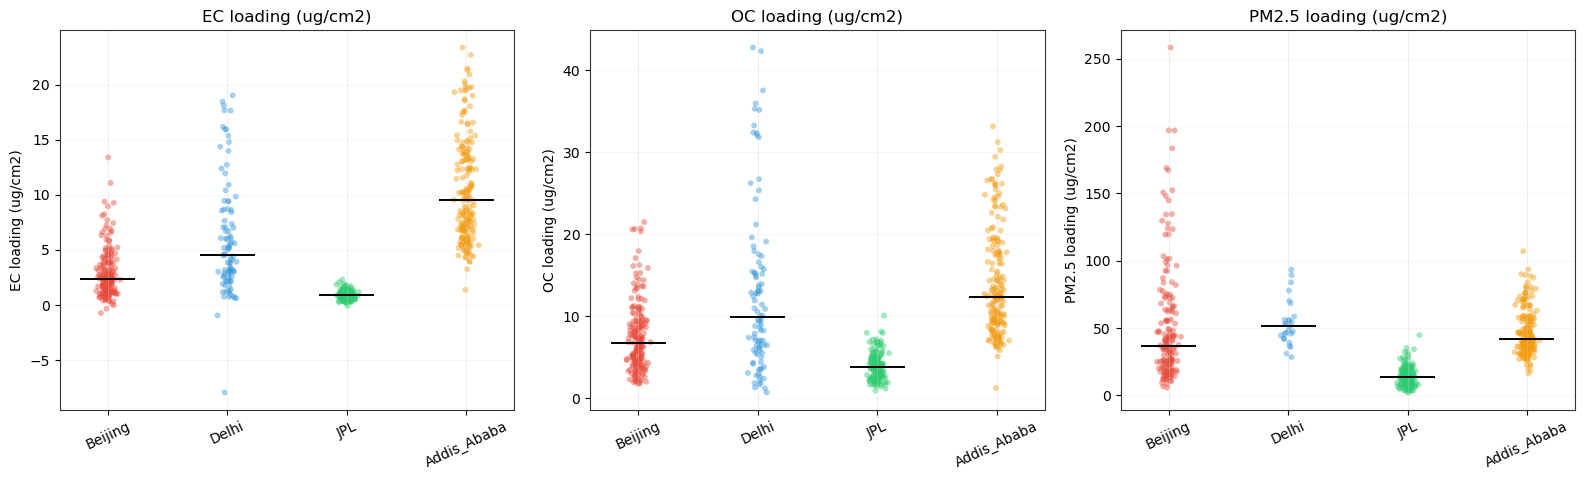

Valid PM2.5 loading rows by site:


,n
SiteName,
Beijing,171
Delhi,27
JPL,156
Addis_Ababa,188


In [4]:
loading_cols = [
    'ec_loading_ug_cm2', 'oc_loading_ug_cm2', 'om_loading_ug_cm2',
    'pm25_loading_ug_cm2', 'hips_bc_loading_ug_cm2', 'iron_loading_ug_cm2'
]
loading_summary = (
    sample_clean.groupby('SiteName')[loading_cols]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .loc[SITE_ORDER]
)
display(loading_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.9))
plot_specs = [
    ('ec_loading_ug_cm2', 'EC loading (ug/cm2)'),
    ('oc_loading_ug_cm2', 'OC loading (ug/cm2)'),
    ('pm25_loading_ug_cm2', 'PM2.5 loading (ug/cm2)'),
]
for ax, (col, label) in zip(axes, plot_specs):
    any_points = False
    for x, site in enumerate(SITE_ORDER, start=1):
        g = sample_clean[sample_clean['SiteName'].eq(site)][col].replace([np.inf, -np.inf], np.nan).dropna()
        if len(g):
            any_points = True
            jitter = np.random.default_rng(42 + x).normal(x, 0.035, len(g))
            ax.scatter(jitter, g, s=18, alpha=0.45, color=SITE_COLORS[site], edgecolor='none')
            ax.hlines(g.median(), x - 0.23, x + 0.23, color='black', lw=1.4)
    ax.set_xticks(range(1, len(SITE_ORDER) + 1), SITE_ORDER, rotation=25)
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.grid(True, axis='y', alpha=0.25)
    if not any_points:
        ax.text(0.5, 0.5, f'No valid {label}\nwith volume + area', transform=ax.transAxes,
                ha='center', va='center', fontsize=10)
fig.tight_layout()
fig.savefig(OUT_DIR / 'spartan_mass_per_area_envelope.png', dpi=160, bbox_inches='tight')
plt.show()

pm25_available = sample_clean.groupby('SiteName')['pm25_loading_ug_cm2'].apply(lambda s: int(s.notna().sum())).loc[SITE_ORDER]
print('Valid PM2.5 loading rows by site:')
display(pm25_available.to_frame('n'))

## 3. Residual Mechanism Screen

The residuals below are defined as:

- `hips_bc = HIPS_Fabs / MAC_VALUE`
- `hips_minus_ec = hips_bc - EC_ftir`
- `hips_minus_ec_rel = (hips_bc - EC_ftir) / EC_ftir`

The table reports signed Pearson/Spearman correlations and their squared values. The plot ranks Addis variables by `Spearman R²`, so it answers which variables explain the most monotonic residual structure while still coloring bars by direction.

The goal is not to prove causality from a correlation table. The goal is to prioritize which mechanisms deserve deeper testing: optical loading, OC/OM composition, total PM mass, iron/dust, lot/calibration, or season.


,site,variable,n,pearson_r,pearson_r2,spearman_r,spearman_r2
47,Addis_Ababa,ec_loading_ug_cm2,190,-0.679,0.462,-0.926,0.858
42,Addis_Ababa,EC_ftir,190,-0.674,0.454,-0.923,0.852
48,Addis_Ababa,oc_loading_ug_cm2,190,-0.650,0.423,-0.884,0.781
49,Addis_Ababa,om_loading_ug_cm2,190,-0.600,0.360,-0.760,0.578
50,Addis_Ababa,pm25_loading_ug_cm2,188,-0.525,0.276,-0.750,0.562
53,Addis_Ababa,pm_ec,188,0.868,0.754,0.701,0.491
44,Addis_Ababa,HIPS_tau,190,-0.476,0.226,-0.642,0.412
43,Addis_Ababa,hips_bc,190,-0.449,0.202,-0.623,0.388
13,Beijing,iron_ec,148,0.361,0.130,0.707,0.500
9,Beijing,oc_ec,163,0.453,0.205,0.609,0.371


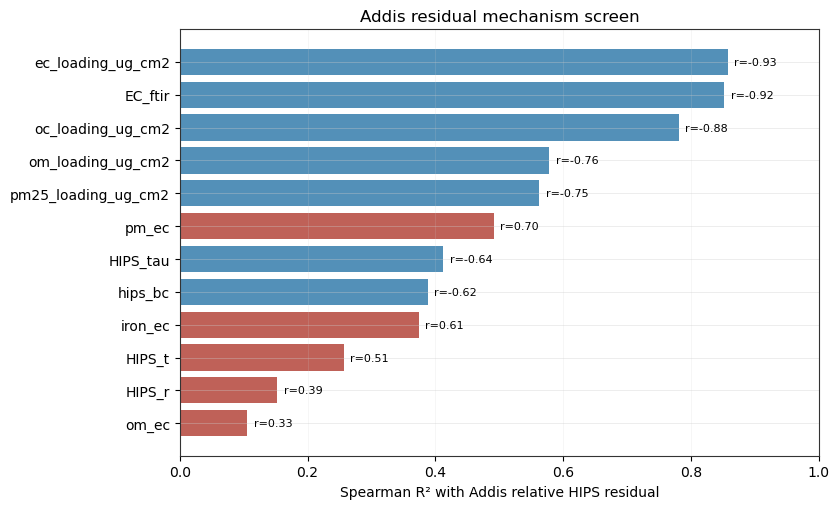

In [5]:
SCREEN_VARS = [
    'EC_ftir', 'hips_bc', 'HIPS_tau', 'HIPS_t', 'HIPS_r',
    'ec_loading_ug_cm2', 'oc_loading_ug_cm2', 'om_loading_ug_cm2', 'pm25_loading_ug_cm2',
    'oc_ec', 'om_ec', 'pm_ec', 'iron_loading_ug_cm2', 'iron_ec',
]

def corr_screen(df, residual_col='hips_minus_ec_rel'):
    rows = []
    for site in SITE_ORDER:
        g_site = df[df['SiteName'].eq(site)]
        for var in SCREEN_VARS:
            g = g_site[[var, residual_col]].replace([np.inf, -np.inf], np.nan).dropna()
            if len(g) >= 5 and g[var].nunique() > 1:
                pearson = g[var].corr(g[residual_col], method='pearson')
                spearman = g[var].corr(g[residual_col], method='spearman')
            else:
                pearson = np.nan
                spearman = np.nan
            rows.append({
                'site': site,
                'variable': var,
                'n': len(g),
                'pearson_r': pearson,
                'pearson_r2': pearson ** 2 if pd.notna(pearson) else np.nan,
                'spearman_r': spearman,
                'spearman_r2': spearman ** 2 if pd.notna(spearman) else np.nan,
            })
    return pd.DataFrame(rows)

screen = corr_screen(sample_clean)
display(
    screen.sort_values(['site', 'spearman_r2'], ascending=[True, False])
    .groupby('site')
    .head(8)
    .round(3)
)

addis_screen = screen[screen['site'].eq('Addis_Ababa')].sort_values('spearman_r2', ascending=False)
fig, ax = plt.subplots(figsize=(8.5, 5.2))
plot = addis_screen.dropna(subset=['spearman_r2']).head(12).iloc[::-1]
colors = ['#B03A2E' if v > 0 else '#2874A6' for v in plot['spearman_r']]
ax.barh(plot['variable'], plot['spearman_r2'], color=colors, alpha=0.8)
ax.set_xlabel('Spearman R² with Addis relative HIPS residual')
ax.set_title('Addis residual mechanism screen')
ax.grid(True, axis='x', alpha=0.25)
for y, (_, row) in enumerate(plot.iterrows()):
    ax.text(row['spearman_r2'] + 0.01, y, f"r={row['spearman_r']:.2f}", va='center', fontsize=8)
ax.set_xlim(0, min(1.0, max(0.1, plot['spearman_r2'].max() * 1.25)))
fig.tight_layout()
fig.savefig(OUT_DIR / 'addis_residual_mechanism_screen.png', dpi=160, bbox_inches='tight')
plt.show()

### Addis Residual Cross-Plots

These are the first plots to inspect after the correlation screen. If Pandey/Lack/Cappa-style composition artifacts are relevant, OC/EC or OC loading should structure the residuals. If optical loading is dominant, `HIPS_tau`, `HIPS_t`, or EC surface loading should structure them.

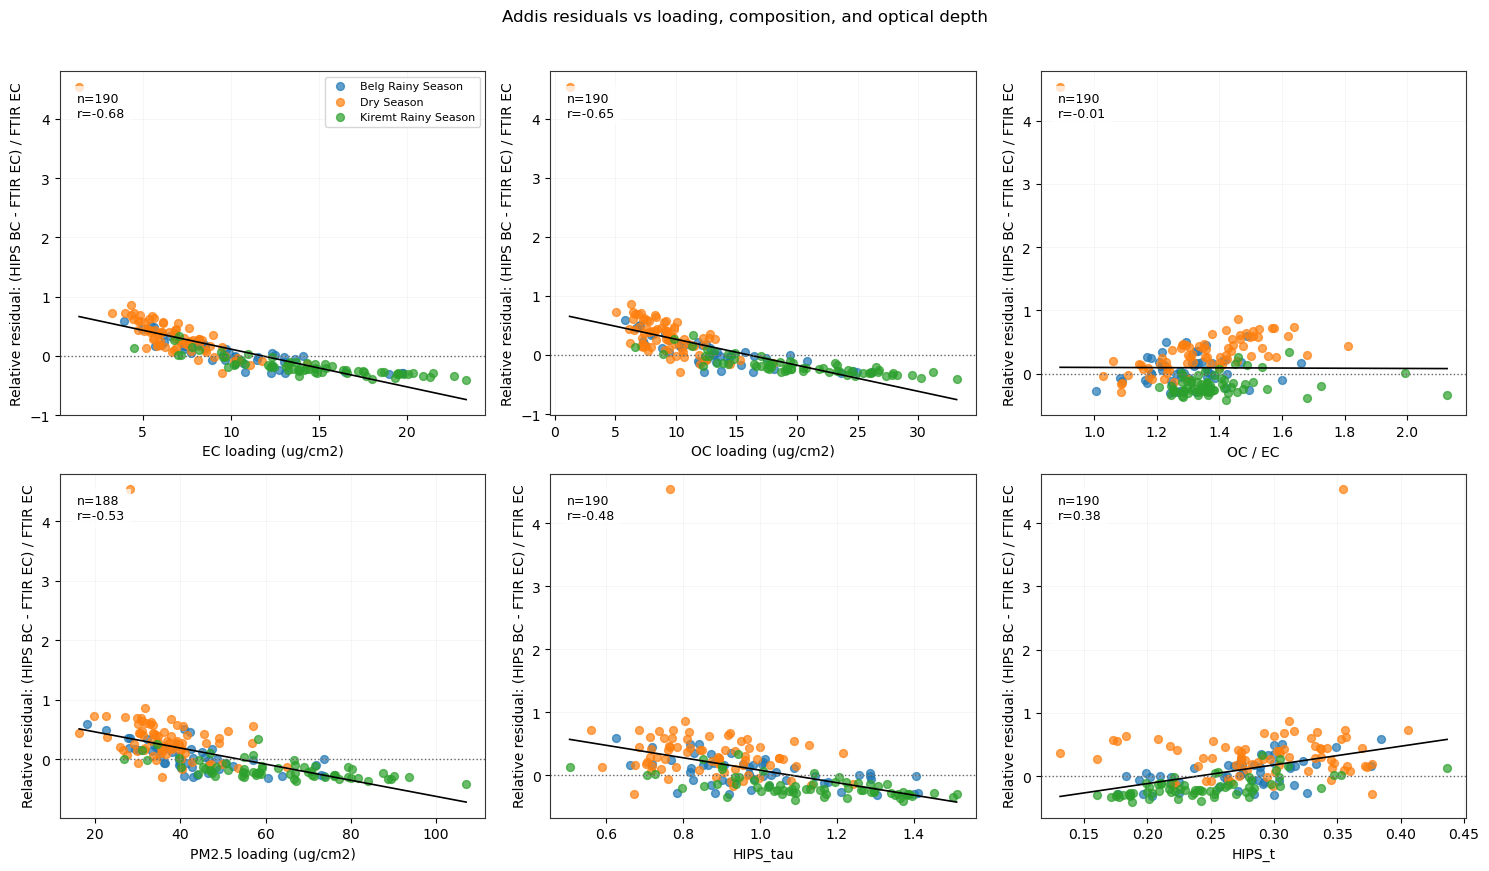

In [6]:
addis = sample_clean[sample_clean['SiteName'].eq('Addis_Ababa')].copy()
resid_specs = [
    ('ec_loading_ug_cm2', 'EC loading (ug/cm2)'),
    ('oc_loading_ug_cm2', 'OC loading (ug/cm2)'),
    ('oc_ec', 'OC / EC'),
    ('pm25_loading_ug_cm2', 'PM2.5 loading (ug/cm2)'),
    ('HIPS_tau', 'HIPS_tau'),
    ('HIPS_t', 'HIPS_t'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
for ax, (x_col, x_label) in zip(axes.ravel(), resid_specs):
    g = addis[[x_col, 'hips_minus_ec_rel', 'ethiopia_season']].replace([np.inf, -np.inf], np.nan).dropna()
    if len(g) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue
    for season, gg in g.groupby('ethiopia_season'):
        ax.scatter(gg[x_col], gg['hips_minus_ec_rel'], s=32, alpha=0.7, label=season)
    if len(g) >= 5 and g[x_col].nunique() > 1:
        slope, intercept, r, p, se = stats.linregress(g[x_col], g['hips_minus_ec_rel'])
        x_line = np.linspace(g[x_col].min(), g[x_col].max(), 100)
        ax.plot(x_line, slope * x_line + intercept, color='black', lw=1.2)
        ax.text(0.04, 0.94, f'n={len(g)}\nr={r:.2f}', transform=ax.transAxes, va='top', fontsize=9,
                bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))
    ax.axhline(0, color='0.4', ls=':', lw=1)
    ax.set_xlabel(x_label)
    ax.set_ylabel('Relative residual: (HIPS BC - FTIR EC) / FTIR EC')
    ax.grid(True, alpha=0.25)
axes[0, 0].legend(fontsize=8, loc='best')
fig.suptitle('Addis residuals vs loading, composition, and optical depth', y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / 'addis_residual_crossplots.png', dpi=160, bbox_inches='tight')
plt.show()

## 4. Slope vs Intercept Separation

A different effective MAC mainly changes scale. A positive intercept or positive `tau` floor points elsewhere: blank/lot mismatch, optical nonlinearity, support-screen/pixelation, or a loaded-sample HIPS/PTFE response.

This section reports three fits by site:

- OLS with intercept: detects slope + floor.
- Through-origin slope: effective MAC if the intercept is forced to zero.
- Theil-Sen: robust slope/intercept sensitivity to leverage points.

,n,ols_slope,ols_intercept,ols_r2,origin_slope,theil_slope,theil_intercept
SiteName,,,,,,,
Beijing,160.0,0.604,0.533,0.652,0.862,0.663,0.469
Delhi,60.0,0.733,0.789,0.796,0.854,0.775,1.254
JPL,130.0,0.814,0.069,0.522,0.936,0.857,0.052
Addis_Ababa,190.0,0.402,2.832,0.764,0.863,0.405,2.842


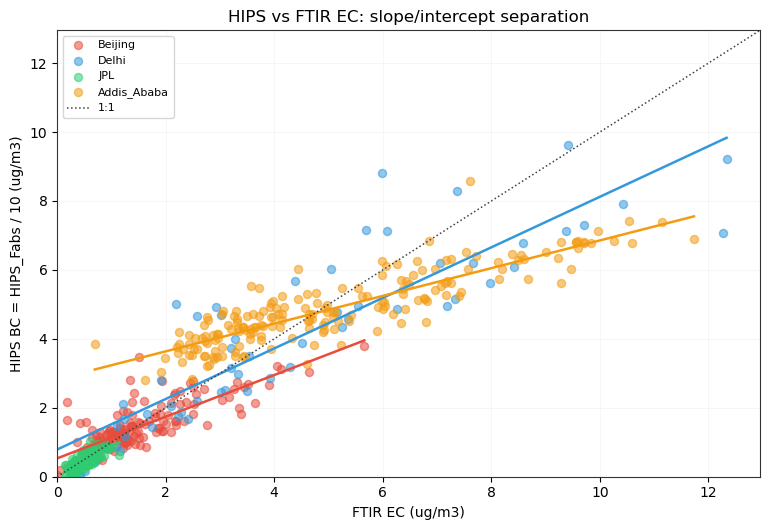

In [7]:
def fit_modes(df, x_col='EC_ftir', y_col='hips_bc'):
    d = df[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    d = d[(d[x_col] > 0) & (d[y_col] > 0)]
    if len(d) < 3 or d[x_col].nunique() < 2:
        return pd.Series({
            'n': len(d), 'ols_slope': np.nan, 'ols_intercept': np.nan, 'ols_r2': np.nan,
            'origin_slope': np.nan, 'theil_slope': np.nan, 'theil_intercept': np.nan,
        })
    x = d[x_col].to_numpy(float)
    y = d[y_col].to_numpy(float)
    ols_slope, ols_intercept, r, p, se = stats.linregress(x, y)
    origin_slope = float(np.dot(x, y) / np.dot(x, x))
    try:
        theil = stats.theilslopes(y, x)
        theil_slope = float(theil.slope)
        theil_intercept = float(theil.intercept)
    except Exception:
        theil_slope = np.nan
        theil_intercept = np.nan
    return pd.Series({
        'n': len(d), 'ols_slope': ols_slope, 'ols_intercept': ols_intercept, 'ols_r2': r ** 2,
        'origin_slope': origin_slope, 'theil_slope': theil_slope, 'theil_intercept': theil_intercept,
    })

fit_summary = sample_clean.groupby('SiteName').apply(fit_modes, include_groups=False).loc[SITE_ORDER]
display(fit_summary.round(3))

fig, ax = plt.subplots(figsize=(7.8, 5.4))
for site in SITE_ORDER:
    g = sample_clean[sample_clean['SiteName'].eq(site)].dropna(subset=['EC_ftir', 'hips_bc'])
    ax.scatter(g['EC_ftir'], g['hips_bc'], s=34, alpha=0.55, color=SITE_COLORS[site], label=site)
    fit = fit_summary.loc[site]
    if pd.notna(fit['ols_slope']):
        x_line = np.linspace(g['EC_ftir'].min(), g['EC_ftir'].max(), 100)
        ax.plot(x_line, fit['ols_slope'] * x_line + fit['ols_intercept'], color=SITE_COLORS[site], lw=1.8)
lim = max(sample_clean['EC_ftir'].max(), sample_clean['hips_bc'].max()) * 1.05
ax.plot([0, lim], [0, lim], color='0.25', lw=1.1, ls=':', label='1:1')
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel('FTIR EC (ug/m3)')
ax.set_ylabel(f'HIPS BC = HIPS_Fabs / {MAC_VALUE} (ug/m3)')
ax.set_title('HIPS vs FTIR EC: slope/intercept separation')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / 'spartan_fit_modes_hips_vs_ftir.png', dpi=160, bbox_inches='tight')
plt.show()

### Addis Binned Median Test

This helps distinguish curvature/compression from a few influential points. If HIPS compresses at high loading, the binned median should bend below the 1:1 line as EC loading increases.

,ec_loading_bin,n,ec_loading_mid,ec_median,hips_median,residual_median,rel_residual_median,tau_median
0,"(1.379, 5.885]",32,5.157,2.531,3.734,1.225,0.499,0.755
1,"(5.885, 7.334]",32,6.764,3.287,4.187,0.919,0.268,0.852
2,"(7.334, 9.491]",31,8.192,3.967,4.660,0.663,0.166,0.960
3,"(9.491, 12.318]",31,10.240,4.977,4.692,-0.435,-0.081,0.956
4,"(12.318, 14.843]",32,13.450,6.595,5.562,-0.974,-0.158,1.132
5,"(14.843, 23.361]",32,18.615,9.250,6.481,-2.752,-0.289,1.319


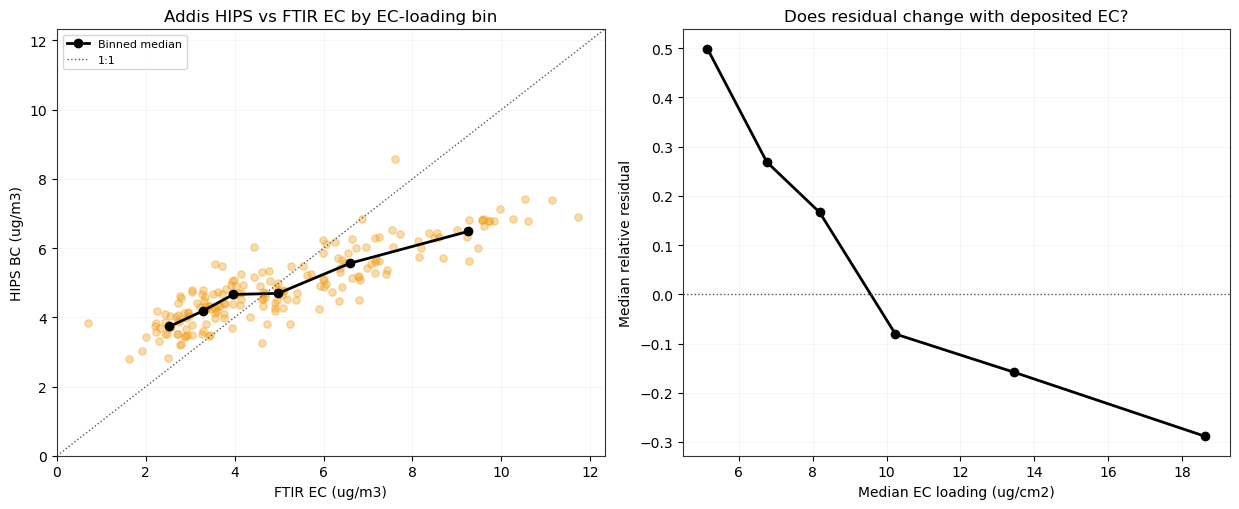

In [8]:
addis_fit = addis.dropna(subset=['ec_loading_ug_cm2', 'EC_ftir', 'hips_bc']).copy()
addis_fit = addis_fit[(addis_fit['ec_loading_ug_cm2'] > 0) & (addis_fit['EC_ftir'] > 0) & (addis_fit['hips_bc'] > 0)]
addis_fit['ec_loading_bin'] = pd.qcut(addis_fit['ec_loading_ug_cm2'], q=6, duplicates='drop')

binned = (
    addis_fit.groupby('ec_loading_bin', observed=True)
    .agg(
        n=('base_filter_id', 'count'),
        ec_loading_mid=('ec_loading_ug_cm2', 'median'),
        ec_median=('EC_ftir', 'median'),
        hips_median=('hips_bc', 'median'),
        residual_median=('hips_minus_ec', 'median'),
        rel_residual_median=('hips_minus_ec_rel', 'median'),
        tau_median=('HIPS_tau', 'median'),
    )
    .reset_index()
)
display(binned.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
ax = axes[0]
ax.scatter(addis_fit['EC_ftir'], addis_fit['hips_bc'], s=28, alpha=0.35, color=SITE_COLORS['Addis_Ababa'])
ax.plot(binned['ec_median'], binned['hips_median'], color='black', marker='o', lw=2, label='Binned median')
lim = max(addis_fit['EC_ftir'].max(), addis_fit['hips_bc'].max()) * 1.05
ax.plot([0, lim], [0, lim], color='0.35', ls=':', lw=1, label='1:1')
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel('FTIR EC (ug/m3)')
ax.set_ylabel('HIPS BC (ug/m3)')
ax.set_title('Addis HIPS vs FTIR EC by EC-loading bin')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

ax = axes[1]
ax.plot(binned['ec_loading_mid'], binned['rel_residual_median'], color='black', marker='o', lw=2)
ax.axhline(0, color='0.35', ls=':', lw=1)
ax.set_xlabel('Median EC loading (ug/cm2)')
ax.set_ylabel('Median relative residual')
ax.set_title('Does residual change with deposited EC?')
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_DIR / 'addis_binned_median_loading_test.png', dpi=160, bbox_inches='tight')
plt.show()

## 5. Lot and Calibration Screen

This is a quick screen, not a replacement for the detailed blank audit in `hips_offset_narrative.ipynb`. A lot/calibration mechanism would be more plausible if residuals or `HIPS_tau` changed sharply by `LotId`, `HIPS_Intercept`, `HIPS_Slope`, or analysis period.

In [9]:
lot_cols = ['LotId', 'HIPS_Intercept', 'HIPS_Slope', 'CalibrationSetId']
addis_lot = addis.dropna(subset=['hips_minus_ec_rel', 'HIPS_tau']).copy()
addis_lot['CoefPair'] = addis_lot['HIPS_Intercept'].astype(str) + ' / ' + addis_lot['HIPS_Slope'].astype(str)
addis_lot['analysis_month'] = addis_lot['AnalysisDate'].dt.to_period('M').astype(str)

def group_screen(df, group_col):
    if group_col not in df.columns:
        return pd.DataFrame()
    out = (
        df.groupby(group_col, dropna=False)
        .agg(
            n=('base_filter_id', 'count'),
            date_min=('date', 'min'),
            date_max=('date', 'max'),
            hips_tau_median=('HIPS_tau', 'median'),
            hips_bc_median=('hips_bc', 'median'),
            ftir_ec_median=('EC_ftir', 'median'),
            rel_residual_median=('hips_minus_ec_rel', 'median'),
            rel_residual_iqr=('hips_minus_ec_rel', lambda s: s.quantile(0.75) - s.quantile(0.25)),
        )
        .sort_values('n', ascending=False)
    )
    return out

for group_col in ['LotId', 'CoefPair', 'analysis_month', 'CalibrationSetId']:
    print('\n' + '=' * 80)
    print(group_col)
    display(group_screen(addis_lot, group_col).round(3).head(12))


LotId


,n,date_min,date_max,hips_tau_median,hips_bc_median,ftir_ec_median,rel_residual_median,rel_residual_iqr
LotId,,,,,,,,
251.0,156,2023-03-29,2024-09-21,0.988,4.798,5.076,-0.059,0.405
248.0,34,2022-12-07,2023-03-22,0.860,4.252,2.826,0.466,0.356



CoefPair


,n,date_min,date_max,hips_tau_median,hips_bc_median,ftir_ec_median,rel_residual_median,rel_residual_iqr
CoefPair,,,,,,,,
1416.2 / -2.783,79,2023-03-29,2023-12-17,0.970,4.722,4.938,-0.058,0.451
1397.0 / -2.687,77,2023-12-20,2024-09-21,1.003,4.891,5.077,-0.060,0.363
1383.2 / -2.544,27,2022-12-28,2023-03-22,0.821,4.132,2.764,0.457,0.487
2262.0 / -5.32,7,2022-12-07,2022-12-25,0.951,4.721,3.045,0.550,0.194



analysis_month


,n,date_min,date_max,hips_tau_median,hips_bc_median,ftir_ec_median,rel_residual_median,rel_residual_iqr
analysis_month,,,,,,,,
2024-08,28,2023-12-20,2024-03-10,0.888,4.324,3.714,0.129,0.283
2025-03,28,2024-06-06,2024-09-21,1.153,5.696,7.505,-0.248,0.160
2024-02,23,2023-08-16,2023-11-05,0.945,4.660,4.725,-0.022,0.496
2023-05,14,2022-12-28,2023-02-08,0.794,4.016,2.425,0.651,0.159
2023-08,14,2023-03-29,2023-05-09,0.921,4.472,4.236,0.050,0.525
2023-09,14,2023-05-17,2023-06-25,1.163,5.702,6.642,-0.121,0.268
2023-12,14,2023-06-28,2023-08-08,1.138,5.610,7.156,-0.219,0.114
2024-04,14,2023-11-08,2023-12-17,0.826,4.029,3.480,0.274,0.219
2024-09,14,2024-03-13,2024-04-21,0.901,4.348,4.769,0.003,0.317



CalibrationSetId


,n,date_min,date_max,hips_tau_median,hips_bc_median,ftir_ec_median,rel_residual_median,rel_residual_iqr
CalibrationSetId,,,,,,,,
HIPS,190,2022-12-07,2024-09-21,0.964,4.713,4.625,0.016,0.454


## 6. AERONET SSA Sensitivity Hook

The existing AERONET notebooks already cover AOD/coarse-mode context. The Pandey et al. 2019 mechanism specifically motivates SSA sensitivity. This cell is intentionally written as a hook because AERONET inversion files may live outside the repo or under user-specific Google Drive paths.

Expected use:

1. Set `AERONET_INVERSION_PATH` to a local AERONET inversion file containing single-scattering albedo columns.
2. Run the cell.
3. Inspect `hips_minus_ec_rel` vs SSA near the HIPS wavelength, using 675 nm SSA if 633 nm is unavailable.

In [10]:
AERONET_INVERSION_PATH = None  # Example: Path('/absolute/path/to/AAU_Jackros_ET inversion file')
AERONET_MISSING = -999.0

def load_aeronet_inversion(path):
    path = Path(path)
    inv = pd.read_csv(path, skiprows=6, na_values=[AERONET_MISSING, -999])
    date_col = next((c for c in inv.columns if 'Date' in c and 'yyyy' in c.lower()), None)
    if date_col is None:
        raise ValueError('Could not find AERONET date column')
    # AERONET daily/all files use different date spellings; try common formats.
    inv['date'] = pd.to_datetime(inv[date_col], format='%d:%m:%Y', errors='coerce')
    if inv['date'].isna().all():
        inv['date'] = pd.to_datetime(inv[date_col], errors='coerce')
    ssa_cols = [c for c in inv.columns if 'Single_Scattering_Albedo' in c or 'SSA' in c]
    keep = ['date'] + ssa_cols
    return inv[keep].dropna(subset=['date'])

if AERONET_INVERSION_PATH is None:
    print('No AERONET inversion path set. Existing AERONET AOD/coarse-mode analyses are in addis_04_aeronet*.ipynb and cross_plots_and_distributions.ipynb.')
else:
    inv = load_aeronet_inversion(AERONET_INVERSION_PATH)
    ssa_candidates = [c for c in inv.columns if '675' in c and ('Single_Scattering_Albedo' in c or 'SSA' in c)]
    if not ssa_candidates:
        ssa_candidates = [c for c in inv.columns if 'Single_Scattering_Albedo' in c or 'SSA' in c]
    if not ssa_candidates:
        raise ValueError('No SSA columns found in AERONET inversion file')
    ssa_col = ssa_candidates[0]
    merged = addis.merge(inv[['date', ssa_col]], on='date', how='left')
    d = merged[[ssa_col, 'hips_minus_ec_rel', 'HIPS_tau', 'oc_ec']].replace([np.inf, -np.inf], np.nan).dropna(subset=[ssa_col, 'hips_minus_ec_rel'])
    print(f'SSA column: {ssa_col}; matched samples: {len(d)}')
    display(d[[ssa_col, 'hips_minus_ec_rel', 'HIPS_tau', 'oc_ec']].describe())
    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(d[ssa_col], d['hips_minus_ec_rel'], c=d['HIPS_tau'], cmap='viridis', s=40, alpha=0.8)
    ax.axhline(0, color='0.35', ls=':', lw=1)
    ax.set_xlabel(ssa_col)
    ax.set_ylabel('Relative residual: (HIPS BC - FTIR EC) / FTIR EC')
    ax.set_title('Addis HIPS residual vs AERONET SSA')
    fig.colorbar(sc, ax=ax, label='HIPS_tau')
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'addis_residual_vs_aeronet_ssa.png', dpi=160, bbox_inches='tight')
    plt.show()

No AERONET inversion path set. Existing AERONET AOD/coarse-mode analyses are in addis_04_aeronet*.ipynb and cross_plots_and_distributions.ipynb.


## 7. IMPROVE Handoff

Do not redo the full IMPROVE comparison here. The working IMPROVE notebooks already handle the larger reference-population question:

- `research/ftir_hips_chem/improve_high_fabs_comparison.ipynb`
- `research/improve_hips_offset/improve_addis_analog_audit.ipynb`
- `research/improve_hips_offset/etad_vs_improve_ec_matched_comparisons.ipynb`

The SPARTAN variables from this notebook that should be used to define Addis-like IMPROVE windows are:

- `HIPS_Fabs`, `HIPS_tau`, and any raw `t/r` proxy available in IMPROVE/FED
- `ec_loading_ug_cm2`
- `oc_loading_ug_cm2` or IMPROVE `OCf` loading analog
- `pm25_loading_ug_cm2`
- `hips_minus_ec_rel` or equivalent `fAbs/MAC - EC`

Avoid selecting IMPROVE only by high `fAbs`; that truncates the response variable and can manufacture weak/compressed regression behavior.

In [11]:
addis_windows = {}
window_cols = [
    'HIPS_Fabs', 'HIPS_tau', 'HIPS_t', 'HIPS_r',
    'ec_loading_ug_cm2', 'oc_loading_ug_cm2', 'om_loading_ug_cm2', 'pm25_loading_ug_cm2',
]
for col in window_cols:
    s = addis[col].replace([np.inf, -np.inf], np.nan).dropna()
    if len(s):
        addis_windows[col] = {
            'n': len(s),
            'min': s.min(),
            'p05': s.quantile(0.05),
            'p25': s.quantile(0.25),
            'median': s.median(),
            'p75': s.quantile(0.75),
            'p95': s.quantile(0.95),
            'max': s.max(),
        }
addis_windows = pd.DataFrame(addis_windows).T
addis_windows.to_csv(OUT_DIR / 'addis_operating_envelope_windows.csv')
display(addis_windows.round(3))

,n,min,p05,p25,median,p75,p95,max
HIPS_Fabs,190.0,28.086,34.681,41.282,47.132,55.707,68.043,85.853
HIPS_tau,190.0,0.504,0.705,0.841,0.964,1.133,1.378,1.512
HIPS_t,190.0,0.131,0.179,0.225,0.274,0.305,0.359,0.437
HIPS_r,190.0,0.188,0.221,0.254,0.277,0.296,0.338,0.557
ec_loading_ug_cm2,190.0,1.380,4.725,6.763,9.491,13.490,19.640,23.361
oc_loading_ug_cm2,190.0,1.230,6.638,9.071,12.353,17.946,26.647,33.179
om_loading_ug_cm2,190.0,0.008,5.476,8.946,11.867,15.762,22.799,33.758
pm25_loading_ug_cm2,188.0,16.254,27.116,34.419,41.559,57.160,79.808,107.060


## Working Interpretation Checklist

Use the outputs above to update the paper story:

- If Addis separates in `HIPS_t/r/tau`, the operating-envelope framing is supported.
- If residuals track OC/EC or OC loading, the Pandey/Lack/Cappa organic/SSA artifact path becomes more important.
- If residuals track `HIPS_tau` or EC loading but not OC/EC, optical loading/compression is the stronger mechanism.
- If lot/calibration groups jump, keep blank/lot mismatch active and cross-check against `hips_offset_narrative.ipynb`.
- If through-origin slopes differ but intercepts remain large, state clearly that MAC variation may explain slope but not the Addis optical floor.
- If AERONET SSA is available and residuals track SSA, that becomes a direct PTFE optical-depth sensitivity result.